<a href="https://colab.research.google.com/github/Bagas-Meriko-newbie/Pengolahan-Citra-Digital/blob/main/UTS%20Pengolahan%20Citra%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **Konversi Citra RGB** ke Grayscale
Definisi:

Citra RGB memiliki 3 kanal warna (*Red, Green, Blue*).

*Grayscale* hanya memiliki satu kanal intensitas (abu-abu), sehingga lebih sederhana untuk analisis.

Tujuan:

1. Mengurangi kompleksitas data.

2. Memudahkan proses seperti deteksi tepi, segmentasi, atau histogram equalization.

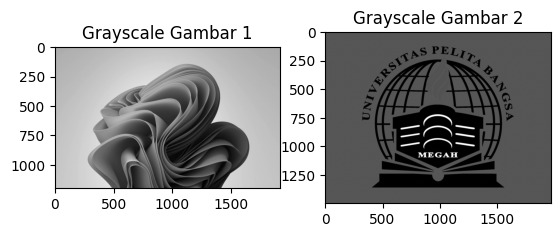

In [12]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img1 = cv2.imread('/bunga citra.jpg')   # logo bunga
img2 = cv2.imread('/logo upb.png')    # logo universitas

# Konversi ke grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.subplot(121), plt.imshow(gray1, cmap='gray'), plt.title('Grayscale Gambar 1')
plt.subplot(122), plt.imshow(gray2, cmap='gray'), plt.title('Grayscale Gambar 2')
plt.show()


Hasil:

1.   Gambar Logo Bunga berubah menjadi nuansa abu-abu.
2.   Logo universitas juga menjadi abu-abu, teks dan simbol tetap terlihat tapi tanpa warna.






2. **Brightness Adjustment & Contrast Enhancement**

Definisi:

*   **Brightness**: menambah/mengurangi intensitas cahaya pada seluruh piksel.
*   **Contrast**: memperbesar perbedaan antara piksel terang dan gelap.

Tujuan:

1.   Brightness untuk memperjelas gambar yang terlalu gelap.
2.   Contrast untuk menonjolkan detail agar lebih mudah dibedakan.






(<Axes: title={'center': 'Contrast Gambar 2'}>,
 Text(0.5, 1.0, 'Contrast Gambar 2'))

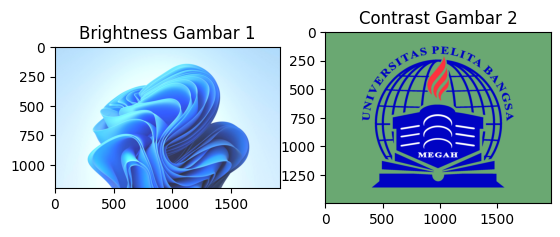

In [36]:
bright1 = cv2.convertScaleAbs(img1, alpha=1.0, beta=50)   # tambah brightness
contrast2 = cv2.convertScaleAbs(img2, alpha=1.5, beta=0)  # tingkatkan contrast

plt.subplot(121), plt.imshow(cv2.cvtColor(bright1, cv2.COLOR_BGR2RGB)), plt.title('Brightness Gambar 1')
plt.subplot(122), plt.imshow(cv2.cvtColor(contrast2, cv2.COLOR_BGR2RGB)), plt.title('Contrast Gambar 2')


**Hasil:**

*   Gambar bunga lebih terang.
*   Logo universitas lebih tegas, garis dan teks lebih jelas.







3. **Transformasi Geometri (Translasi, Rotasi, Scaling, Flipping)**

Definisi:


*   **Translasi**: menggeser posisi citra.
*   **Rotasi**: memutar citra dengan sudut tertentu.
* **Scaling**: memperbesar atau memperkecil ukuran citra.
* **Flipping**: membalik citra secara horizontal/vertikal.

**Tujuan**:

Digunakan untuk augmentasi data, manipulasi posisi, atau simulasi pergerakan objek.

(<Axes: title={'center': 'Flipping'}>,
 Text(0.5, 1.0, 'Flipping'))

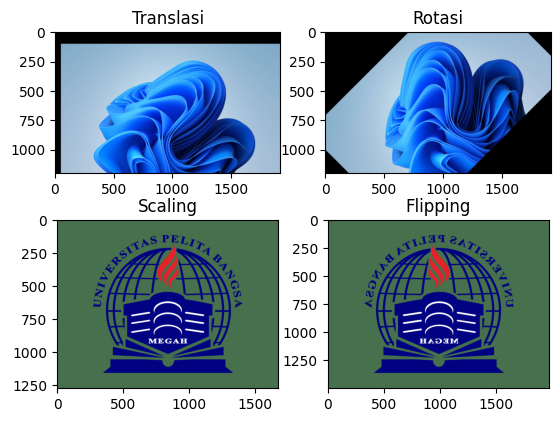

In [35]:
rows, cols = img1.shape[:2]
M_translate = np.float32([[1,0,50],[0,1,100]])
translated = cv2.warpAffine(img1, M_translate, (cols, rows))

M_rotate = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
rotated = cv2.warpAffine(img1, M_rotate, (cols, rows))

scaled = cv2.resize(img2, None, fx=0.85, fy=0.85)
flipped = cv2.flip(img2, 1)
plt.subplot(221), plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)), plt.title('Translasi')
plt.subplot(222), plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)), plt.title('Rotasi')
plt.subplot(223), plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)), plt.title('Scaling')
plt.subplot(224), plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB)), plt.title('Flipping')


**Hasil**:

* Gambar bunga bergeser dan berputar.

* Logo universitas diperkecil dan dibalik horizontal.

4. **Histogram Equalization**

**Definisi**

* Teknik untuk menyebarkan distribusi intensitas piksel agar lebih merata.

* Membuat detail pada area gelap/terang lebih terlihat.

**Tujuan:**

* Meningkatkan kualitas visual.

* Berguna untuk citra dengan kontras rendah.

(<Axes: title={'center': 'Histogram Equalization Gambar 2'}>,
 Text(0.5, 1.0, 'Histogram Equalization Gambar 2'))

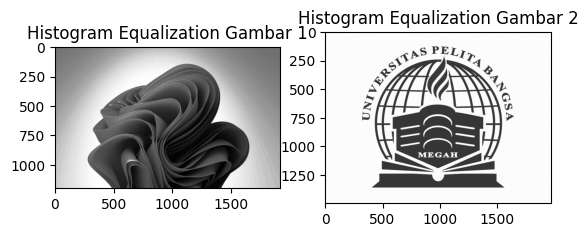

In [34]:
equalized1 = cv2.equalizeHist(gray1)
equalized2 = cv2.equalizeHist(gray2)

plt.subplot(121), plt.imshow(equalized1, cmap='gray'), plt.title('Histogram Equalization Gambar 1')
plt.subplot(122), plt.imshow(equalized2, cmap='gray'), plt.title('Histogram Equalization Gambar 2')

**Hasil**:

* Gambar bunga lebih detail pada area gelap.

* Logo universitas lebih jelas, terutama teks putih di atas latar biru.

5. **Filtering Spasial (Smoothing & Sharpening)**

Definisi:

* **Smoothing (Gaussian Blur)**: mengurangi noise dengan meratakan piksel sekitar.

* Sharpening: menonjolkan tepi dan detail dengan filter khusus.

Tujuan:

* **Smoothing** untuk membersihkan citra dari gangguan.

* **Sharpening** untuk mempertegas garis dan detail.

(<Axes: title={'center': 'Sharpening Gambar 2'}>,
 Text(0.5, 1.0, 'Sharpening Gambar 2'))

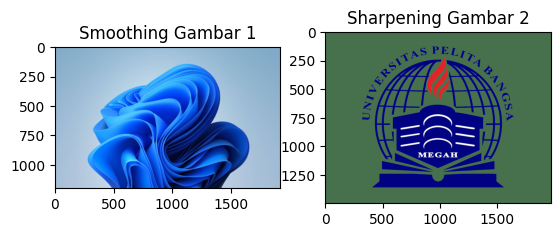

In [38]:
smooth1 = cv2.GaussianBlur(img1, (5,5), 0)

kernel_sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpen2 = cv2.filter2D(img2, -1, kernel_sharpen)

plt.subplot(121), plt.imshow(cv2.cvtColor(smooth1, cv2.COLOR_BGR2RGB)), plt.title('Smoothing Gambar 1')
plt.subplot(122), plt.imshow(cv2.cvtColor(sharpen2, cv2.COLOR_BGR2RGB)), plt.title('Sharpening Gambar 2')

**Hasil**:

* Gambar bunga lebih halus, noise berkurang.

* Logo universitas lebih tajam, garis dan teks lebih menonjol.

🔹 Kesimpulan

* Grayscale → menyederhanakan citra.

* Brightness/Contrast → memperjelas pencahayaan dan detail.

* Transformasi Geometri → memanipulasi posisi, orientasi, ukuran.

* Histogram Equalization → meningkatkan kualitas visual.

* Filtering Spasial → smoothing untuk noise, sharpening untuk detail.